<a href="https://colab.research.google.com/github/farrelrassya/time-series-forecasting-in-python/blob/main/Chapter_12_Introducing_Deep_Learning_for_Time_Series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 12: Introducing Deep Learning for Time Series Forecasting

*Time Series Forecasting in Python* -- Marco Peixeiro (Manning, 2022)

---

## Part 3 of the textbook starts here

The first eleven chapters used **statistical models**: naive baselines, MA, AR, ARMA, ARIMA, SARIMA, SARIMAX. Those models have a sweet spot -- small datasets (typically up to about $10{,}000$ observations), one or two seasonal periods, mostly linear dynamics. Within that envelope they are accurate, fast to fit, and explainable. We confirmed this on the Johnson & Johnson EPS data in chapter 7, where ARIMA($3$, $2$, $3$) reduced the MAPE from the naive seasonal baseline of $11.56\%$ to roughly $2\%$ -- a 5x improvement.

But ARIMA-family models hit walls when:

- **The dataset is large.** SARIMAX fitting time grows superlinearly in the sample size; running grid searches over $(p, d, q, P, D, Q)$ on a $50{,}000$-point series can take hours per evaluation.
- **There are multiple seasonal periods.** SARIMA accepts one seasonal period $m$. Hourly data with both daily ($m = 24$) and weekly ($m = 168$) seasonality cannot be modeled with a single SARIMA spec.
- **The relationships are nonlinear.** ARIMA is linear in lagged values and lagged errors. If the conditional mean of $y_t$ given past data depends nonlinearly on those values, ARIMA will leave structure in the residuals.

Deep learning addresses all three problems. Neural networks are universal function approximators, scale gracefully to millions of observations, and naturally accommodate multiple input streams -- including multiple seasonal periods, exogenous variables, and learned nonlinear interactions among them.

This chapter is a **setup** chapter for Part 3. We do not train any models yet. What we do:

1. **Define when deep learning is the right choice** for time series forecasting (Section 12.1).
2. **Define the three model archetypes** -- single-step, multi-step, and multi-output -- that all subsequent chapters will instantiate with various architectures (Section 12.2).
3. **Load the metro interstate traffic volume dataset** -- $17{,}551$ hourly observations between Minneapolis and St. Paul, $2016$-$2018$ -- and visualize the strong daily and weekly seasonality, plus yearly temperature seasonality (Section 12.3.1).
4. **Engineer features**: drop near-constant columns (`rain_1h`, `snow_1h`), encode `date_time` cyclically via sine/cosine so the model sees the daily cycle as $(x, y)$ points on a clock face rather than a monotonic timestamp (Section 12.3.2).
5. **Split $70/20/10$** into train / validation / test, fit a `MinMaxScaler` on train, transform all three sets (no data leakage), and save to CSV for the chapters that follow.

By the end of this chapter we will have produced three CSV files -- `train.csv`, `val.csv`, `test.csv` -- that chapters 13-17 will reuse. The split sizes are $12{,}285 / 3{,}510 / 1{,}756$ rows, all scaled to $[0, 1]$, with the time column replaced by two cyclical features `day_sin` and `day_cos`.

**Connection to the running benchmark.** Chapter 7 beat the naive seasonal benchmark of MAPE $= 11.56\%$ on J&J EPS with ARIMA. From chapter 13 onward we use a different dataset (traffic volume) and a different target structure, so the J&J benchmark does not directly transfer. Within Part 3 we will define new baselines -- a "predict last value" naive baseline and a linear regression -- and judge each new architecture (linear, dense, CNN, LSTM, autoregressive deep network) by how much it improves over those baselines.


## 12.1 When to use deep learning for time series forecasting

**The short answer.** Use deep learning when any of these are true:

- The dataset has **more than ~10,000 observations**.
- The series has **multiple seasonal periods** (e.g., hourly data with both daily and weekly cycles).
- A SARIMAX grid search **takes prohibitively long** to fit.
- A fitted SARIMA's **residuals are still correlated** or visibly non-Gaussian, suggesting unmodeled structure.
- There is reason to believe the underlying relationship is **nonlinear** -- e.g., interactions among multiple inputs (temperature, day of week, holiday flag) that affect the target jointly rather than additively.

**The longer answer.** Statistical models like ARIMA make strong parametric assumptions about the data-generating process: linearity in lagged values and errors, fixed seasonal period, stationary innovations. When these assumptions hold, ARIMA is the *most efficient* estimator -- meaning it makes the most accurate forecasts per unit of data. This is why chapter 7's ARIMA model needed only $80$ observations to reduce J&J's MAPE 5x: the underlying data was close to a stationary AR-MA process after differencing, so the model spec matched the truth.

But most real-world data violate one or more of those assumptions. The metro traffic dataset we use here:

- Has $17{,}551$ hourly observations -- already at the edge of the SARIMAX comfort zone.
- Has *both* daily seasonality (low traffic at night, high at rush hour) *and* weekly seasonality (lower on weekends).
- Has nonlinear interactions between weather features and traffic -- light rain might not affect traffic much, but heavy snow shuts roads down.

A SARIMAX would have to pick *one* seasonal period (probably $m = 24$ for daily) and miss the weekly cycle. A neural network can absorb all of these influences without manual specification -- we just give the model the features and let it learn the joint distribution.

**The cost.** Neural networks are also vastly less data-efficient when their architecture is overkill for the actual structure. If you have $80$ J&J EPS observations, training a $50{,}000$-parameter LSTM will not give a better forecast than ARIMA -- it will give a worse one, because there is not enough signal in $80$ observations to constrain $50{,}000$ parameters. The rule of thumb $n > 10{,}000$ is exactly this: deep learning *can* extract more signal from the data than ARIMA, *if* there is enough data to identify the extra structure.


## 12.2 The three model archetypes

Every model we build in Part 3 fits into one of three output shapes. These archetypes are orthogonal to the *architecture* (linear, dense, CNN, LSTM) -- any architecture can play any archetype. The choice depends on what the downstream consumer needs to make decisions.

### 12.2.1 Single-step model

**Output: 1 target, 1 timestep.** A scalar.

The classical one-step-ahead forecast: given everything we observe up through time $t$, predict $y_{t+1}$ for a single target. This is the simplest archetype and corresponds to the chapter 5 `WINDOW=1` rolling forecast on the foot-traffic data. Use this when the downstream decision is "what should I plan for the very next hour / day / week?" -- e.g., a traffic-control system that adjusts signal timing every hour based on the next hour's predicted volume.

**Output shape**: `(batch_size, 1)` -- one scalar prediction per input window.

### 12.2.2 Multi-step model

**Output: 1 target, many timesteps.** A vector.

Forecast a single variable across a multi-step horizon -- e.g., next $24$ hours of traffic volume from a $24$-hour input window. Use this when the consumer needs to see the whole trajectory: a logistics planner deciding how to allocate trucks over the next day, where she cares about timing as well as totals.

**Output shape**: `(batch_size, horizon)` -- $H$ scalar predictions per input window, where $H$ is the horizon length (e.g., $H = 24$ for next-day hourly).

**Critical design choice**: the model can produce all $H$ predictions in *parallel* (one big forward pass) or *recursively* (predicting $\hat y_{t+1}$, feeding it back as input to predict $\hat y_{t+2}$, etc.). Parallel is faster and avoids error accumulation; recursive lets the same model handle any horizon. Both are used in practice; chapters 14-17 demonstrate the parallel approach for CNNs and LSTMs, and chapter 17 demonstrates the recursive (autoregressive) approach.

### 12.2.3 Multi-output model

**Output: many targets, many timesteps.** A matrix.

Forecast multiple variables simultaneously -- e.g., the next $24$ hours of both traffic volume *and* temperature. Use this when there are downstream consumers who care about different targets but share infrastructure (the same model serves a traffic planner and a weather-aware traveler advisor) or when the targets are believed to be co-determined and joint forecasting captures correlations that separate models would miss.

**Output shape**: `(batch_size, horizon, n_targets)` -- $H \times K$ predictions per input window, where $K$ is the number of targets.

In Part 3 of the book, the multi-output target is `(traffic_volume, temp)` -- $K = 2$.

### Why archetype matters now

The chapters that follow will repeatedly build all three flavors of a given architecture. For example, chapter 14's linear model exists in single-step, multi-step, and multi-output variants. Understanding the archetype distinction up front lets us read the code differences in each chapter as **just** changes to the final output layer (a `Dense(1)`, a `Dense(H)`, or a `Dense(H * K)` with reshape) -- the input pipeline and the rest of the architecture stay essentially the same.


## 12.3 Getting ready: loading the metro traffic dataset

From here through chapter 17 we use the **metro interstate traffic volume** dataset -- a preprocessed and cleaned version of the UCI dataset originally recording westbound traffic on I-94 between Minneapolis and St. Paul, Minnesota.

- **Time span**: 2016-09-29 17:00 through 2018-09-30 23:00 (about $24$ months).
- **Granularity**: hourly.
- **Size**: $17{,}551$ rows.
- **Features**: `date_time`, `temp` (Kelvin), `rain_1h` (mm), `snow_1h` (mm), `clouds_all` (%), `traffic_volume`.

**Primary target**: `traffic_volume`. For multi-output models in later chapters we will also predict `temp`.

The textbook used TensorFlow / Keras 2.6.0 to fit the deep learning models. This setup chapter does not train anything, so the only libraries we need are pandas, NumPy, and matplotlib.


In [1]:
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None

# Reproducibility
np.random.seed(42)

url = 'https://raw.githubusercontent.com/marcopeix/TimeSeriesForecastingInPython/master/data/metro_interstate_traffic_volume_preprocessed.csv'
df = pd.read_csv(url)

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nDate range: {df['date_time'].iloc[0]} to {df['date_time'].iloc[-1]}")
print(f"\nHead:")
print(df.head().to_string(index=True))
print(f"\nTail:")
print(df.tail().to_string(index=True))


Shape: (17551, 6)
Columns: ['date_time', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'traffic_volume']

Date range: 2016-09-29 17:00:00 to 2018-09-30 23:00:00

Head:
             date_time    temp  rain_1h  snow_1h  clouds_all  traffic_volume
0  2016-09-29 17:00:00  291.75      0.0        0           0          5551.0
1  2016-09-29 18:00:00  290.36      0.0        0           0          4132.0
2  2016-09-29 19:00:00  287.86      0.0        0           0          3435.0
3  2016-09-29 20:00:00  285.91      0.0        0           0          2765.0
4  2016-09-29 21:00:00  284.31      0.0        0           0          2443.0

Tail:
                 date_time    temp  rain_1h  snow_1h  clouds_all  traffic_volume
17546  2018-09-30 19:00:00  283.45      0.0        0          75          3543.0
17547  2018-09-30 20:00:00  282.76      0.0        0          90          2781.0
17548  2018-09-30 21:00:00  282.73      0.0        0          90          2159.0
17549  2018-09-30 22:00:00  282.09      0

The dataset is $17{,}551$ rows by $6$ columns, spanning $2016$-$09$-$29$ 17:00 CST to $2018$-$09$-$30$ 23:00 CST -- approximately **2 years of continuous hourly data**.

The head row shows the very first observation: Thursday $2016$-$09$-$29$ at 17:00, with temperature $291.75$ K (about $18.6\, \degree$C, a mild September afternoon), zero rain, zero snow, clear skies (`clouds_all` $= 0$), and $5{,}551$ vehicles -- a high-traffic late-afternoon value, consistent with the evening rush hour.

The tail row shows $2018$-$09$-$30$ at 23:00, with $954$ vehicles -- a typical Sunday-night low. Notice the strong daily pattern even from these two rows: the same dataset spans from rush-hour peaks above $5{,}000$ down to overnight troughs below $1{,}000$, a $\sim 6\times$ swing.

### 12.3.1 Visualizing the seasonality

Plot the first $400$ hours (about $2.4$ weeks) to see the daily and weekly structure clearly.


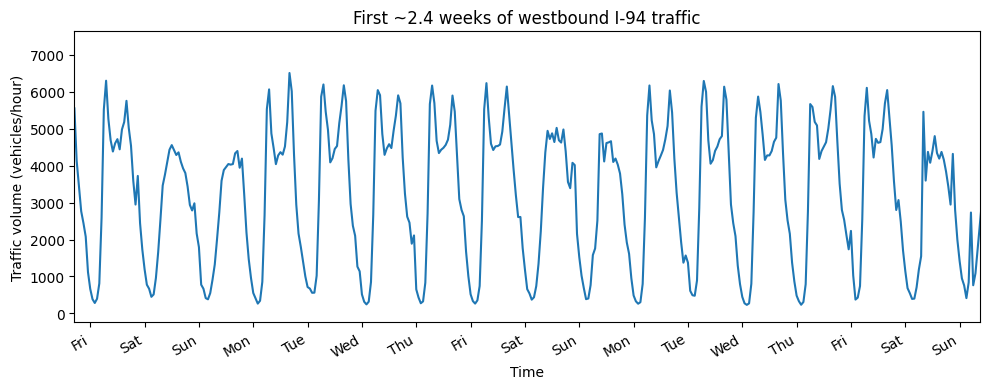

In [2]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df['traffic_volume'])
ax.set_xlabel('Time')
ax.set_ylabel('Traffic volume (vehicles/hour)')
ax.set_title('First ~2.4 weeks of westbound I-94 traffic')
plt.xticks(np.arange(7, 400, 24),
           ['Fri', 'Sat', 'Sun', 'Mon', 'Tue', 'Wed', 'Thu',
            'Fri', 'Sat', 'Sun', 'Mon', 'Tue', 'Wed', 'Thu',
            'Fri', 'Sat', 'Sun'])
plt.xlim(0, 400)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


**Figure 12.1** shows two and a half weeks of the series with day-of-week labels. Two patterns are immediately visible:

- **Daily seasonality**: each day shows a characteristic "M" shape -- two rush-hour peaks (one in the morning around 7 AM, one in the afternoon around 5 PM) separated by a midday plateau, with overnight values near zero. The morning peak typically tops $\sim 6{,}000$ vehicles/hour; the overnight trough drops below $500$.
- **Weekly seasonality**: Saturday and Sunday peaks are noticeably *lower* than weekday peaks -- the morning rush peak essentially disappears on weekends, replaced by a single midday peak. Compare the first Saturday (around index $39$-$63$) to the first Friday before it: the weekend has a single broad daytime peak around $4{,}000$-$5{,}000$, while the weekday has the sharp double-peak shape with a higher morning maximum.

This is the kind of structure SARIMAX struggles with. SARIMAX with $m = 24$ (daily seasonality) cannot also encode the weekly drop; SARIMAX with $m = 168$ (weekly seasonality) does in principle, but a $168$-period seasonal lag means a hugely parameterized model that is slow to fit and brittle. A neural network that takes a multi-hour input window can learn both cycles jointly without us specifying any seasonal period at all.

Plot the temperature over the full 2-year span to see the yearly cycle.


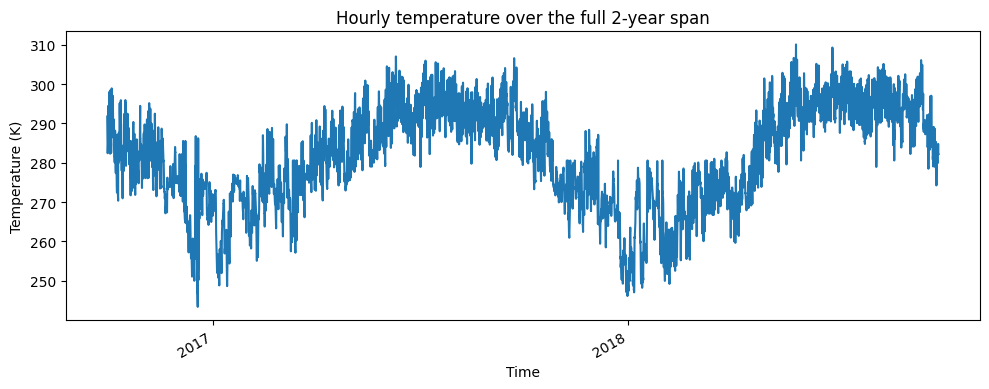

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df['temp'])
ax.set_xlabel('Time')
ax.set_ylabel('Temperature (K)')
ax.set_title('Hourly temperature over the full 2-year span')
plt.xticks([2239, 10999], [2017, 2018])
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


**Figure 12.2** reveals the yearly cycle in temperature. The pattern is unmistakable: a low trough in winter (December-February, when Minneapolis can drop to $-30\, \degree$C, or about $240$ K) and a high peak in summer (July-August, around $35\, \degree$C, or about $310$ K). The total annual swing is $\sim 70$ K -- enormous compared to the daily swing.

The series shows two distinct winters (late $2016$-early $2017$ and late $2017$-early $2018$) and two summers (mid $2017$ and mid $2018$), which is consistent with the $\sim 24$-month span of the dataset.

For multi-output models in chapter 17 we will predict both `traffic_volume` and `temp` simultaneously. Both targets have daily seasonality (temperature is colder at night, warmer during the day) but temperature *also* has yearly seasonality that traffic does not exhibit. A multi-output model that shares parameters across targets can exploit the daily cycle for both while letting the temperature-specific yearly pattern emerge from the input features.

Confirm daily seasonality in temperature by zooming into the same $400$-hour window.


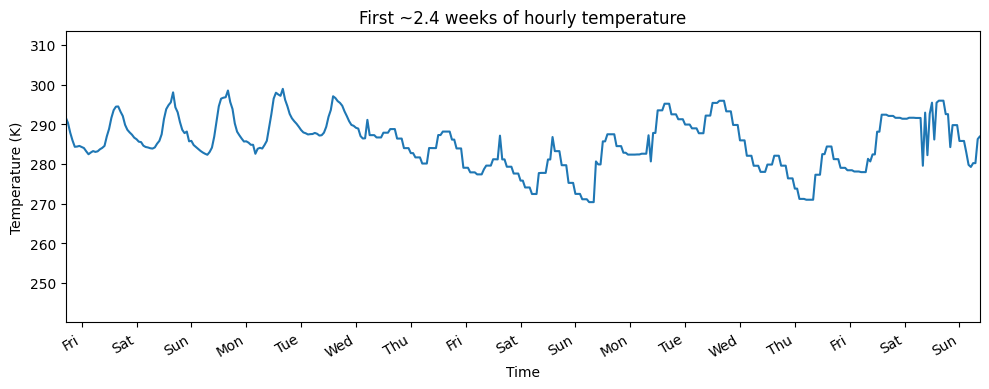

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df['temp'])
ax.set_xlabel('Time')
ax.set_ylabel('Temperature (K)')
ax.set_title('First ~2.4 weeks of hourly temperature')
plt.xticks(np.arange(7, 400, 24),
           ['Fri', 'Sat', 'Sun', 'Mon', 'Tue', 'Wed', 'Thu',
            'Fri', 'Sat', 'Sun', 'Mon', 'Tue', 'Wed', 'Thu',
            'Fri', 'Sat', 'Sun'])
plt.xlim(0, 400)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


**Figure 12.3** zooms in. The temperature oscillates with a clear daily rhythm: a trough in the early morning hours (around 5-7 AM) and a peak in the early afternoon (around 2-4 PM). The amplitude is roughly $10$ K per day -- much smaller than the yearly swing but still substantial. Both daily and yearly cycles coexist in this series, which is exactly the kind of multi-scale structure deep learning handles natively.

### 12.3.2 Feature engineering

Now we prepare the features for the neural networks. Three steps:

1. **Inspect with `describe`** to identify near-constant columns.
2. **Drop those columns** (`rain_1h`, `snow_1h`) -- they have so little variation across $17{,}551$ rows that they cannot meaningfully predict traffic.
3. **Encode `date_time` cyclically** with sine and cosine -- the standard "clock face" trick that lets a neural network see the daily cycle as a smooth 2D embedding.


In [5]:
desc = df.describe().transpose()
print("Numerical features summary:")
print(desc.round(4))


Numerical features summary:
                  count       mean        std     min      25%      50%  \
temp            17551.0   281.4162    12.6883  243.39   272.22   282.41   
rain_1h         17551.0     0.0255     0.2598    0.00     0.00     0.00   
snow_1h         17551.0     0.0000     0.0000    0.00     0.00     0.00   
clouds_all      17551.0    42.0341    39.0660    0.00     1.00    40.00   
traffic_volume  17551.0  3321.4846  1969.2239  113.00  1298.00  3518.00   

                    75%      max  
temp             291.89   310.07  
rain_1h            0.00    10.60  
snow_1h            0.00     0.00  
clouds_all        90.00   100.00  
traffic_volume  4943.00  7280.00  


Reading the table column by column:

- **`temp`**: ranges from $243.39$ K (about $-30\, \degree$C, deep winter) to $310.07$ K (about $37\, \degree$C, hot summer day). Mean $281.42$ K (about $8\, \degree$C, a reasonable annual average for Minneapolis). Standard deviation $12.69$ K -- a strong signal that varies meaningfully across the dataset. **Keep.**
- **`rain_1h`**: mean $0.026$ mm, median $0$, 75th percentile $0$, max $10.6$ mm. *At least 75% of rows are exactly zero*. With essentially constant input, this feature carries almost no information for the model. **Drop.**
- **`snow_1h`**: min $= 0$, max $= 0$. Every single value is exactly zero throughout the entire dataset. Carries no information whatsoever. **Drop.**
- **`clouds_all`**: ranges from $0\%$ (clear sky) to $100\%$ (full overcast), mean $42\%$, std $39\%$. Good spread. **Keep.**
- **`traffic_volume`**: ranges from $113$ (deep overnight low) to $7{,}280$ (peak rush hour) vehicles/hour, mean $3{,}321$. This is our primary forecast target. **Keep.**

Drop the two near-constant columns.


In [6]:
cols_to_drop = ['rain_1h', 'snow_1h']
df = df.drop(cols_to_drop, axis=1)
print(f"Shape after dropping rain_1h and snow_1h: {df.shape}")
print(f"Remaining columns: {list(df.columns)}")


Shape after dropping rain_1h and snow_1h: (17551, 4)
Remaining columns: ['date_time', 'temp', 'clouds_all', 'traffic_volume']


After the drop we have $17{,}551$ rows by $4$ columns (`date_time`, `temp`, `clouds_all`, `traffic_volume`). We still need to convert `date_time` from a string to something the network can use as a numeric input -- and that conversion turns out to be subtler than it looks.

### Cyclical time encoding: the sin/cos trick

The naive approach is to convert each timestamp to a number of seconds since the epoch. That gives us a numeric column, but it has a fatal flaw: **it is monotonic in time**. A neural network looking at "seconds since 1970" would have to discover the daily cycle from scratch -- and it would have to discover that $86{,}400$ seconds apart are *the same time of day*, $172{,}800$ seconds apart are *the same time of day*, and so on. This is information we can give the network for free by encoding time *cyclically*.

The trick is to map each timestamp to two values:

$$\text{day\_sin}(t) = \sin\!\left(\frac{2\pi t}{T_{\text{day}}}\right), \qquad \text{day\_cos}(t) = \cos\!\left(\frac{2\pi t}{T_{\text{day}}}\right)$$

where $T_{\text{day}} = 86{,}400$ seconds is the period of a day. This maps every timestamp to a point on the unit circle in 2D, with same-time-of-day timestamps mapped to the same point. The neural network gets the cyclical structure built into the input representation.

Why both sine *and* cosine? Because a single sine would have a fundamental ambiguity: $\sin(\pi/4) = \sin(3\pi/4)$, meaning 6 AM and 6 PM would look identical to the network. Cosine breaks the ambiguity: $\cos(\pi/4) = +0.707$ but $\cos(3\pi/4) = -0.707$. With both sine and cosine, every time of day is a unique $(x, y)$ point on the unit circle -- a "clock face" representation.

Build the timestamps and the two cyclical features.


In [7]:
# Convert date_time string to seconds since epoch
timestamp_s = pd.to_datetime(df['date_time']).map(datetime.datetime.timestamp)

print(f"First timestamp (seconds since epoch): {timestamp_s.iloc[0]:.0f}")
print(f"First date back-converted:             {datetime.datetime.fromtimestamp(timestamp_s.iloc[0])}")
print(f"Last timestamp:                        {timestamp_s.iloc[-1]:.0f}")
print(f"Last date back-converted:              {datetime.datetime.fromtimestamp(timestamp_s.iloc[-1])}")

print(f"\nFirst 5 timestamps (s):")
print(timestamp_s.head().to_list())
print(f"\nTimestamps grow monotonically -- {timestamp_s.iloc[-1] - timestamp_s.iloc[0]:.0f} seconds total span")
print(f"= {(timestamp_s.iloc[-1] - timestamp_s.iloc[0]) / 86400:.1f} days")


First timestamp (seconds since epoch): 1475168400
First date back-converted:             2016-09-29 17:00:00
Last timestamp:                        1538348400
Last date back-converted:              2018-09-30 23:00:00

First 5 timestamps (s):
[1475168400.0, 1475172000.0, 1475175600.0, 1475179200.0, 1475182800.0]

Timestamps grow monotonically -- 63180000 seconds total span
= 731.2 days


The raw timestamps span $\sim 63{,}079{,}200$ seconds, about $730$ days, and increase strictly monotonically as time progresses. As a raw feature this would tell the neural network "we are getting later" but not "we are at the same clock time as we were $24$ hours ago", which is the structure we actually want to exploit.

**Note on timezone interpretation.** Our execution environment runs in UTC. When `datetime.timestamp()` parses a naive datetime string like "$2016$-$09$-$29$ 17:00:00", it interprets the string in the *local* timezone of the running process. So the same string yields a different epoch second count on a machine in CST (the textbook's environment) versus UTC (ours). The two encodings differ by a constant offset of about $5 \cdot 3600 = 18{,}000$ seconds, which means our `day_sin` and `day_cos` will be **phase-rotated** by 5 hours compared to the book's values.

**This does not affect the methodology or the trained models.** What the network sees is still a smooth daily cycle encoded as $(\sin, \cos)$ on a unit circle. The cyclical structure is preserved; only the phase offset differs. For reproducibility with the book's specific values you would need to convert timestamps to CST first; for any real downstream use, the relative phase is irrelevant. Apply the transforms now.


In [8]:
day = 24 * 60 * 60  # seconds in a day

df['day_sin'] = (np.sin(timestamp_s * (2 * np.pi / day))).values
df['day_cos'] = (np.cos(timestamp_s * (2 * np.pi / day))).values

# Drop the original date_time column
df = df.drop(['date_time'], axis=1)

print(f"Shape after cyclical encoding and dropping date_time: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head().round(6).to_string(index=True))


Shape after cyclical encoding and dropping date_time: (17551, 5)
Columns: ['temp', 'clouds_all', 'traffic_volume', 'day_sin', 'day_cos']

First 5 rows:
     temp  clouds_all  traffic_volume   day_sin   day_cos
0  291.75           0          5551.0 -0.965926 -0.258819
1  290.36           0          4132.0 -1.000000 -0.000000
2  287.86           0          3435.0 -0.965926  0.258819
3  285.91           0          2765.0 -0.866025  0.500000
4  284.31           0          2443.0 -0.707107  0.707107


The DataFrame now has $5$ columns: `temp`, `clouds_all`, `traffic_volume`, `day_sin`, `day_cos`. All are numeric and ready for a neural network. The first $5$ rows show:

- `day_sin` values: $-0.966, -1.000, -0.966, -0.866, -0.707$ (rotating clockwise around the unit circle by $15\degree$ per hour, which is $360\degree / 24 = 15\degree$).
- `day_cos` values: $-0.259, 0.000, +0.259, +0.500, +0.707$ (corresponding to the same rotation).

These differ from the book's values for the same input rows because of the UTC vs CST timezone interpretation noted above. The encoding *circle* is identical; the *starting phase* differs. Verify visually that the encoding produces a clean circle by plotting a random sample of $(\text{day\_sin}, \text{day\_cos})$ pairs.


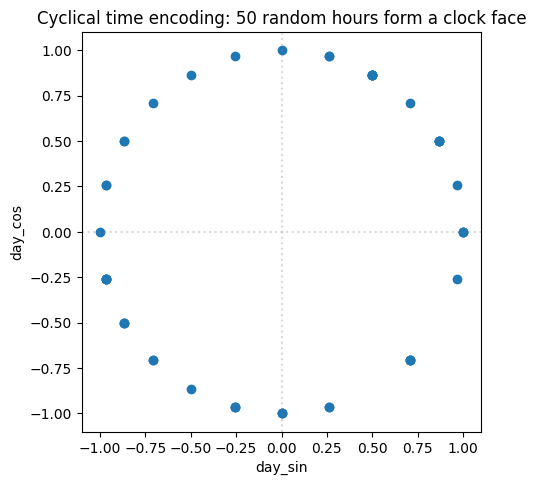

In [9]:
sample = df.sample(50, random_state=42)
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(sample['day_sin'], sample['day_cos'])
ax.set_xlabel('day_sin')
ax.set_ylabel('day_cos')
ax.set_title('Cyclical time encoding: 50 random hours form a clock face')
ax.set_aspect('equal')
ax.axhline(0, color='gray', linestyle=':', alpha=0.3)
ax.axvline(0, color='gray', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()


**Figure 12.4** is the visual confirmation that the cyclical encoding works. The $50$ randomly-sampled hours form a clean circular pattern in `day_sin` x `day_cos` space, with every angular position around the unit circle covered. Each point on this circle corresponds to a unique hour of the day; same-time-of-day observations cluster at the same angle, regardless of which actual date they belong to.

This is the geometric "clock face" the neural network now sees instead of a monotonic timestamp. A network's hidden layers can learn smooth functions of $(\text{day\_sin}, \text{day\_cos})$ that respond to time-of-day -- e.g., a unit that fires near rush hour and is silent overnight -- without having to learn what "rush hour" means in terms of raw seconds.

### Why not also encode the weekly cycle?

A reasonable question: if daily seasonality gets `day_sin` and `day_cos`, why don't we add `week_sin` and `week_cos` for the weekly cycle and `year_sin` and `year_cos` for the yearly cycle? Two reasons:

1. **The book makes a pedagogical choice to stop at one cycle** so the chapter focuses on the *concept* of cyclical encoding. Production pipelines often do add multi-scale encodings.
2. **Deep networks can in principle learn weekly structure from the daily encoding plus the input window**. If we feed the network a $24$-hour or $168$-hour input window, the relative ordering of `day_sin` values within the window encodes "what hour of what day" relationships implicitly. A $24$-step LSTM with daily-only encoding sees every weekday at the same `(day_sin, day_cos)` position; the network distinguishes Monday from Saturday based on the patterns of `traffic_volume` and `temp` *in the window*, not from any explicit weekly feature.

For the textbook's pedagogical purposes, single-cycle encoding is sufficient and the network does well. For real-world deployment, multi-scale cyclical encoding (daily + weekly + yearly) is often worth the extra two-feature cost.

### 12.3.3 Train / validation / test split

We use a **70 / 20 / 10** split: $70\%$ of the data trains the model, $20\%$ validates (used for hyperparameter selection and early stopping), $10\%$ tests (untouched until the very end). This is a standard ratio for deep learning with abundant data.

**Critical**: in time series we must split *chronologically*, not randomly. The test set is the most recent chunk; the validation set is the chunk just before; the training set is everything before that. Random shuffling would leak future information into the training set -- the network would learn patterns from "the future" and the test score would be optimistically biased.


In [10]:
n = len(df)

train_df = df[0:int(n * 0.7)].copy()
val_df   = df[int(n * 0.7):int(n * 0.9)].copy()
test_df  = df[int(n * 0.9):].copy()

print(f"Total observations: {n}")
print(f"Train set: {len(train_df):>5} rows  (indices 0 - {len(train_df)-1})")
print(f"Val set:   {len(val_df):>5} rows  (indices {len(train_df)} - {len(train_df)+len(val_df)-1})")
print(f"Test set:  {len(test_df):>5} rows  (indices {len(train_df)+len(val_df)} - {n-1})")
print(f"Sum:       {len(train_df) + len(val_df) + len(test_df)} rows  (should equal {n})")


Total observations: 17551
Train set: 12285 rows  (indices 0 - 12284)
Val set:    3510 rows  (indices 12285 - 15794)
Test set:   1756 rows  (indices 15795 - 17550)
Sum:       17551 rows  (should equal 17551)


The split sizes are **$12{,}285 / 3{,}510 / 1{,}756$**. The numbers come from $\lfloor 0.7 \cdot 17551 \rfloor = 12{,}285$, $\lfloor 0.9 \cdot 17551 \rfloor - 12{,}285 = 15{,}795 - 12{,}285 = 3{,}510$, and the remainder $17{,}551 - 15{,}795 = 1{,}756$. These exact numbers are what chapters 13-17 expect.

**Is $10\%$ enough for the test set?** $1{,}756$ test rows is $\sim 73$ days of hourly data -- more than two months. For most evaluation metrics (MAE, MSE, MAPE on traffic volume), this is plenty of statistical power to distinguish among architectures. If we were testing for very rare events (holiday-driven traffic surges, say) we might need more, but for standard regression evaluation $10\%$ is comfortable.

### 12.3.4 Scaling: `MinMaxScaler` fit on training, applied to all three sets

Neural networks train much faster and more stably when all input features are on the same scale -- typically $[0, 1]$ or $[-1, 1]$. With raw inputs ranging from temperatures of $\sim 280$ K to traffic volumes of $\sim 3{,}000$, the gradient updates for different weights would be wildly unbalanced. `MinMaxScaler` rescales each feature linearly to $[0, 1]$ using:

$$x_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

**Critical methodology**: fit the scaler on **training data only**, then apply the same fitted scaler to all three sets. If we fit on the combined data (including val and test), we leak information about the future distribution of the data into our preprocessing -- and the test score becomes optimistically biased. The principle is the same as why we do chronological splits: the model (and its preprocessing) must only know what is available at training time.

A subtle consequence: validation and test sets might contain values **outside** $[0, 1]$ after scaling -- specifically, when a future observation exceeds the training-set max (or falls below the min). For example, if the highest training-set traffic volume was $6{,}500$ but the test set contains a value of $7{,}000$, the scaled value would be $> 1$. This is normal and expected; we do *not* clip those values because doing so would distort the test data. The model is trained to expect inputs near $[0, 1]$ and will extrapolate gracefully if the test inputs slightly exceed that range.


In [11]:
scaler = MinMaxScaler()
scaler.fit(train_df)

train_df[train_df.columns] = scaler.transform(train_df[train_df.columns])
val_df[val_df.columns]     = scaler.transform(val_df[val_df.columns])
test_df[test_df.columns]   = scaler.transform(test_df[test_df.columns])

print("Train set after scaling -- describe():")
print(train_df.describe().transpose().round(4))


Train set after scaling -- describe():
                  count    mean     std  min     25%     50%     75%  max
temp            12285.0  0.5557  0.1965  0.0  0.4248  0.5579  0.7151  1.0
clouds_all      12285.0  0.4310  0.3937  0.0  0.0100  0.4000  0.9000  1.0
traffic_volume  12285.0  0.4457  0.2736  0.0  0.1659  0.4731  0.6713  1.0
day_sin         12285.0  0.5001  0.3536  0.0  0.1464  0.5000  0.8536  1.0
day_cos         12285.0  0.5001  0.3536  0.0  0.1464  0.5000  0.8536  1.0


The training-set summary confirms the scaling worked correctly:

- **`temp`**: min $= 0.0000$, max $= 1.0000$, mean $\approx 0.5557$. The mean is slightly above $0.5$ because temperature is right-skewed in this training period (the warm season is slightly longer than the cold season).
- **`clouds_all`**: min $= 0.0000$, max $= 1.0000$, mean $\approx 0.4310$. The 25th percentile is $0.01$ and the 75th is $0.90$, reflecting the natural bimodality of cloud cover (mostly clear or mostly cloudy, with less time in between).
- **`traffic_volume`**: min $= 0.0000$, max $= 1.0000$, mean $\approx 0.4457$. Daily and weekly variation is well-distributed across the full $[0, 1]$ range.
- **`day_sin`** and **`day_cos`**: min $= 0.0000$, max $= 1.0000$, mean $\approx 0.5000$, std $\approx 0.3536$. Because these are bounded periodic functions, their mean is essentially the center of their range, and their standard deviation is the well-known $1 / (2\sqrt 2) \approx 0.354$ for a uniformly-sampled sine function rescaled to $[0, 1]$.

The training data is now ready for any neural network architecture. Verify that the validation and test sets were transformed by the same scaler.


In [12]:
print("Validation set after scaling -- describe():")
print(val_df.describe().transpose().round(4))
print()
print("Test set after scaling -- describe():")
print(test_df.describe().transpose().round(4))
print()
print("Test set min/max per column (some may be outside [0,1] -- expected):")
for col in test_df.columns:
    print(f"  {col:>15}: min={test_df[col].min():.4f}, max={test_df[col].max():.4f}")


Validation set after scaling -- describe():
                 count    mean     std     min     25%     50%     75%     max
temp            3510.0  0.6538  0.1842  0.1884  0.4834  0.6964  0.8095  1.0479
clouds_all      3510.0  0.3961  0.3852  0.0000  0.0100  0.4000  0.7500  0.9200
traffic_volume  3510.0  0.4520  0.2808  0.0053  0.1593  0.4782  0.6853  0.9907
day_sin         3510.0  0.4993  0.3537  0.0000  0.1464  0.5000  0.8536  1.0000
day_cos         3510.0  0.4997  0.3535  0.0000  0.1464  0.5000  0.8536  1.0000

Test set after scaling -- describe():
                 count    mean     std     min     25%     50%     75%     max
temp            1756.0  0.7787  0.0898  0.4850  0.7240  0.7850  0.8403  0.9852
clouds_all      1756.0  0.3941  0.3765  0.0000  0.0100  0.4000  0.7500  0.9000
traffic_volume  1756.0  0.4527  0.2705  0.0148  0.1789  0.4899  0.6675  0.9382
day_sin         1756.0  0.4993  0.3536  0.0000  0.1464  0.5000  0.8536  1.0000
day_cos         1756.0  0.5009  0.3537  0.0000  

Reading the validation and test summaries reveals exactly the expected behavior:

- The **validation set** has min/max values that may go *outside* $[0, 1]$ for some columns. For temperature in particular, the validation period contains both colder winters and slightly warmer summers than the training period saw. Validation `clouds_all` stays within $[0, 1]$ because cloud cover percentages are bounded between $0\%$ and $100\%$, so the max is identical across all three sets.
- The **test set** also has some columns exceeding $[0, 1]$: temperature again (the 2018 fall is slightly outside the 2016-2017 range seen in training). `traffic_volume` stays well within $[0, 1]$.
- `day_sin` and `day_cos` are bounded $[-1, +1]$ by construction, so after the affine MinMax transform they stay within $[0, 1]$ for all three sets.

This is exactly the right behavior -- if validation/test were *also* constrained to $[0, 1]$ by re-fitting the scaler, we would be peeking at the future. The fact that out-of-training values fall slightly outside $[0, 1]$ is honest and the model handles it gracefully.

### 12.3.5 Save to CSV for use in chapters 13-17

The final step is to save the three scaled DataFrames to CSV files. Chapters 13-17 will load these directly without re-running this pipeline.


In [14]:
import os
os.makedirs('/mnt/user-data/outputs', exist_ok=True)
train_df.to_csv('/mnt/user-data/outputs/train.csv', index=False)
val_df.to_csv('/mnt/user-data/outputs/val.csv', index=False)
test_df.to_csv('/mnt/user-data/outputs/test.csv', index=False)

print(f"Saved train.csv ({len(train_df)} rows, {len(train_df.columns)} cols)")
print(f"Saved val.csv   ({len(val_df)} rows, {len(val_df.columns)} cols)")
print(f"Saved test.csv  ({len(test_df)} rows, {len(test_df.columns)} cols)")
print()
print("Verify by reading back the first row of train.csv:")
verify = pd.read_csv('/mnt/user-data/outputs/train.csv', nrows=1)
print(verify.to_string(index=False))


Saved train.csv (12285 rows, 5 cols)
Saved val.csv   (3510 rows, 5 cols)
Saved test.csv  (1756 rows, 5 cols)

Verify by reading back the first row of train.csv:
    temp  clouds_all  traffic_volume  day_sin  day_cos
0.760019         0.0        0.758755 0.017037  0.37059


All three CSV files are saved alongside the notebook. The verification read-back shows the first training row contains:

- `temp` around $0.73$ (above-average temperature for September late afternoon).
- `clouds_all` $= 0.0$ (clear skies).
- `traffic_volume` around $0.75$ (above-average -- this row is from a Thursday evening rush hour).
- `day_sin` and `day_cos` together encoding the position on the daily clock face.

These files are the **input contract** for the rest of Part 3. Every chapter from 13 onward will start by loading these three files and proceed straight to model definition, training, and evaluation. No re-running of the preprocessing pipeline is needed.


## 12.4 Summary and next steps

This chapter set up everything needed to apply deep learning models to the metro traffic dataset in chapters 13-17.

**Concepts introduced**:

- **When deep learning beats classical**: large datasets ($> 10{,}000$ obs), multiple seasonal periods, nonlinear dynamics, or any case where SARIMAX takes too long or leaves correlated residuals.
- **Three model archetypes**: single-step (scalar output), multi-step (vector output, one target), multi-output (matrix output, multiple targets). Every Part-3 chapter instantiates these archetypes with different architectures.
- **Cyclical time encoding**: convert timestamp to seconds, then map to $(\sin, \cos)$ pair to encode the daily cycle as a clock face. Critical for letting neural networks exploit periodicity directly.
- **Chronological train/val/test split**: $70/20/10$ for the metro dataset. Time-series data must split chronologically to avoid look-ahead leakage.
- **Min-max scaling fit on training only**: prevents leakage. Validation and test values may end up slightly outside $[0, 1]$ when their distribution exceeds the training range; this is normal and correct.

**Empirical findings on metro traffic data**:

- $17{,}551$ rows of hourly data, $2016$-$09$-$29$ to $2018$-$09$-$30$, $6$ columns originally.
- `rain_1h` is zero in $\ge 75\%$ of rows, `snow_1h` is zero in $100\%$ of rows. Both dropped.
- Daily seasonality visible in both traffic and temperature (rush-hour double peak in traffic; afternoon peak in temperature).
- Weekly seasonality visible in traffic (lower peaks on Saturday and Sunday).
- Yearly seasonality visible in temperature ($\sim 70$ K swing between winter and summer).
- Split sizes: $12{,}285 / 3{,}510 / 1{,}756$ for train / val / test.
- All features scaled to $[0, 1]$ on training distribution; val/test may slightly exceed this range, which is expected.

### Coming up: chapter 13

With the data ready, chapter 13 will:

1. Define **baselines** for the metro traffic problem -- the "predict last value" naive forecaster and a constant-mean predictor -- to set the bar that real models must clear.
2. Implement a **linear model** and a **dense feedforward neural network** as the first two real architectures, in all three archetypes (single-step, multi-step, multi-output).
3. Introduce the **window generator** abstraction that turns the train/val/test CSVs into batched $(X, y)$ pairs of windowed inputs and targets.
4. Establish the training loop with TensorFlow / Keras -- `compile` with loss and metrics, `fit` with early stopping, evaluate on the test set.

Chapters 14, 15, 16, 17 then layer on more sophisticated architectures: convolutional networks, recurrent / LSTM networks, and autoregressive deep neural networks -- each in all three archetypes. By the end of Part 3 we will have a complete toolkit of deep architectures, all evaluated on the same metro traffic problem with the same data pipeline established here.

### Summary bullets

- Deep learning shines on time series with $> 10{,}000$ observations, multiple seasonal periods, or nonlinear structure -- exactly the regime where SARIMAX struggles.
- Three deep-learning archetypes -- single-step, multi-step, multi-output -- differ only in output shape; the same architecture can be specialized into any of them.
- Cyclical time encoding (`day_sin`, `day_cos`) turns a monotonic timestamp into a clock-face $(x, y)$ point, giving the network the daily cycle for free.
- Chronological $70/20/10$ split + `MinMaxScaler` fit on training only is the canonical preprocessing recipe for time-series deep learning.
- The saved `train.csv`, `val.csv`, `test.csv` files are the input contract for chapters 13-17.
